#  Exercice 1 — Tutoriel Guidé : Clustering sur le Jeu de Données Iris

**Cours : Machine Learning — Clustering | Master 2**  
**Auteur : Aurélie Montarnal — IMT Mines Albi**

---

## Objectif
Ce notebook vous guide pas à pas à travers les trois algorithmes de clustering vus en cours :
1. **Clustering Hiérarchique** (Chapitre 1)
2. **K-Means** (Chapitre 2)
3. **DBSCAN** (Chapitre 3)

Vous apprendrez à les appliquer, visualiser et évaluer sur le célèbre jeu de données **Iris**.

> 🎯 **Ce notebook est entièrement guidé — lisez chaque cellule, exécutez-la, et observez les résultats.**


## 0. Imports et chargement des données

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA

# Reproductibilité
np.random.seed(42)

# Style graphique
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")
print("✅ Imports OK")


✅ Imports OK


In [3]:
# Chargement du jeu de données Iris
iris = load_iris()
X = iris.data           # Features (4 dimensions)
y_true = iris.target    # Labels vrais (utilisés uniquement pour l'évaluation finale)
feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df['species'] = [target_names[i] for i in y_true]

print(f"Dimensions du dataset : {X.shape}")
print(f"\nFeatures : {feature_names}")
print(f"Classes : {target_names}")
print(f"\nAperçu :")
df.head()


Dimensions du dataset : (150, 4)

Features : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes : ['setosa' 'versicolor' 'virginica']

Aperçu :


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 1. Exploration du Jeu de Données

Avant d'appliquer un algorithme, il est essentiel de comprendre les données.


In [4]:
# Statistiques descriptives
print("=== Statistiques descriptives ===")
df.head()


=== Statistiques descriptives ===


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


/usr/lib/python3/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/lib/python3/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/lib/python3/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/lib/python3/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/lib/python3/dist-packages/seaborn/axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)
/usr/lib/python3/dist-packages/seaborn/axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)
/usr/lib/pytho

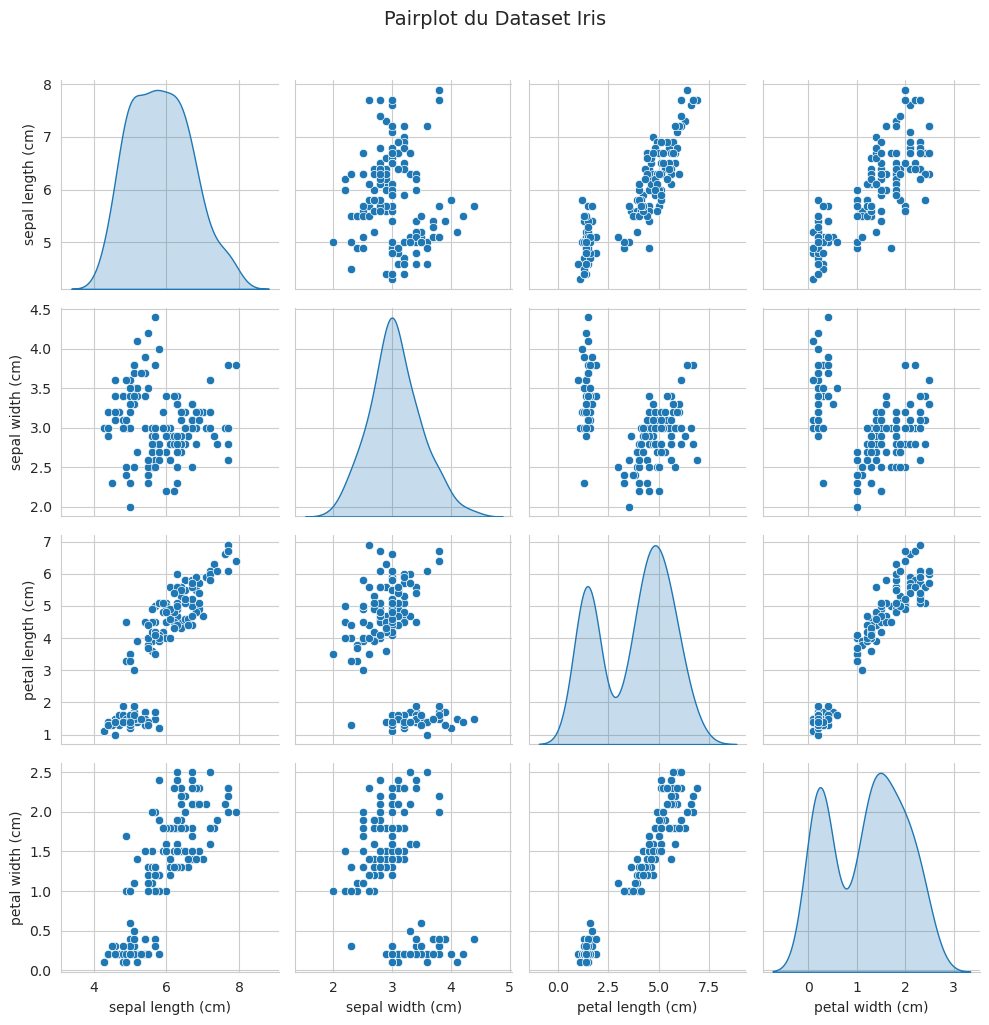

In [5]:
# Visualisation par paires (pairplot)
sns.pairplot(df, palette='Set2', diag_kind='kde')
plt.suptitle("Pairplot du Dataset Iris", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('iris_pairplot.png', dpi=100, bbox_inches='tight')
plt.show()


## 2. Prétraitement : Normalisation

Avant d'appliquer tout algorithme de clustering basé sur des distances, il est **crucial** de normaliser les données.

> ⚠️ Sans normalisation, les features avec de grandes valeurs dominent le calcul des distances !


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Avant normalisation — moyenne :", X.mean(axis=0).round(2))
print("Avant normalisation — std     :", X.std(axis=0).round(2))
print()
print("Après normalisation — moyenne :", X_scaled.mean(axis=0).round(2))
print("Après normalisation — std     :", X_scaled.std(axis=0).round(2))


Avant normalisation — moyenne : [5.84 3.06 3.76 1.2 ]
Avant normalisation — std     : [0.83 0.43 1.76 0.76]

Après normalisation — moyenne : [-0. -0. -0. -0.]
Après normalisation — std     : [1. 1. 1. 1.]


---

## 3. Clustering Hiérarchique (Chapitre 1)

Le clustering hiérarchique (agglomératif) fusionne progressivement les clusters les plus proches. On visualise le résultat via un **dendrogramme**.

### 3.1 Dendrogramme


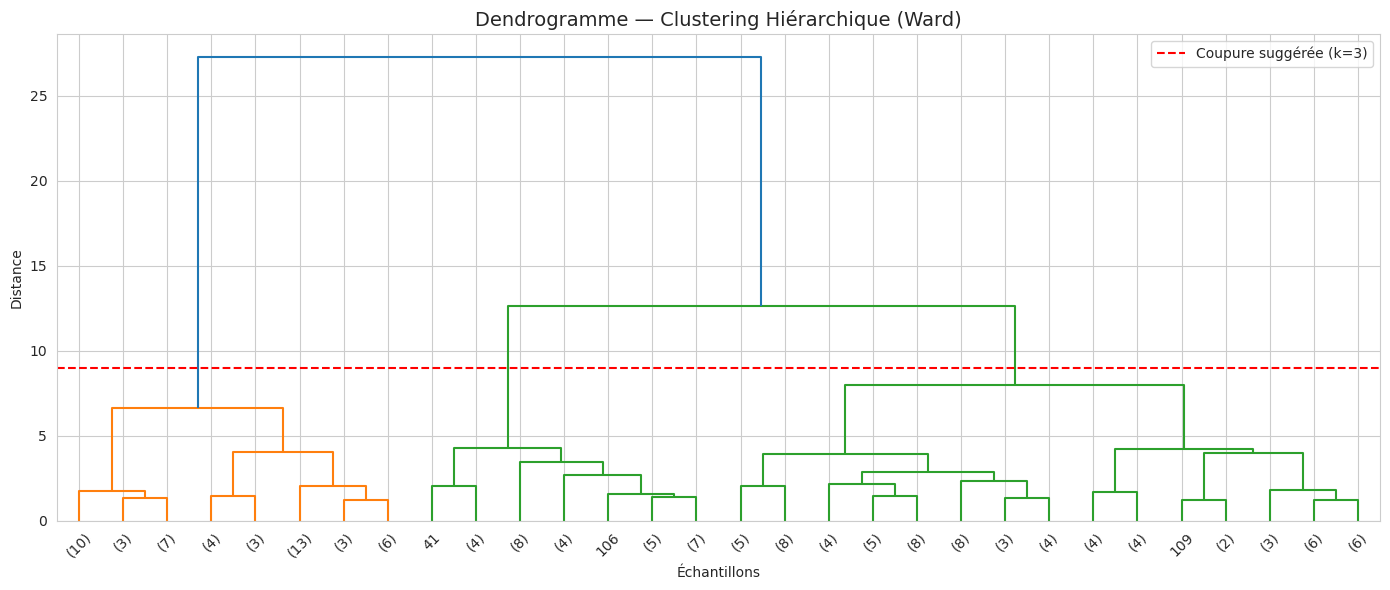

👆 La ligne rouge indique où 'couper' pour obtenir 3 clusters.


In [7]:
# Calcul du linkage (liaison complète)
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=45, leaf_font_size=10)
plt.title("Dendrogramme — Clustering Hiérarchique (Ward)", fontsize=14)
plt.xlabel("Échantillons")
plt.ylabel("Distance")
plt.axhline(y=9, color='red', linestyle='--', label='Coupure suggérée (k=3)')
plt.legend()
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=100, bbox_inches='tight')
plt.show()
print("👆 La ligne rouge indique où 'couper' pour obtenir 3 clusters.")


### 3.2 Application avec k=3

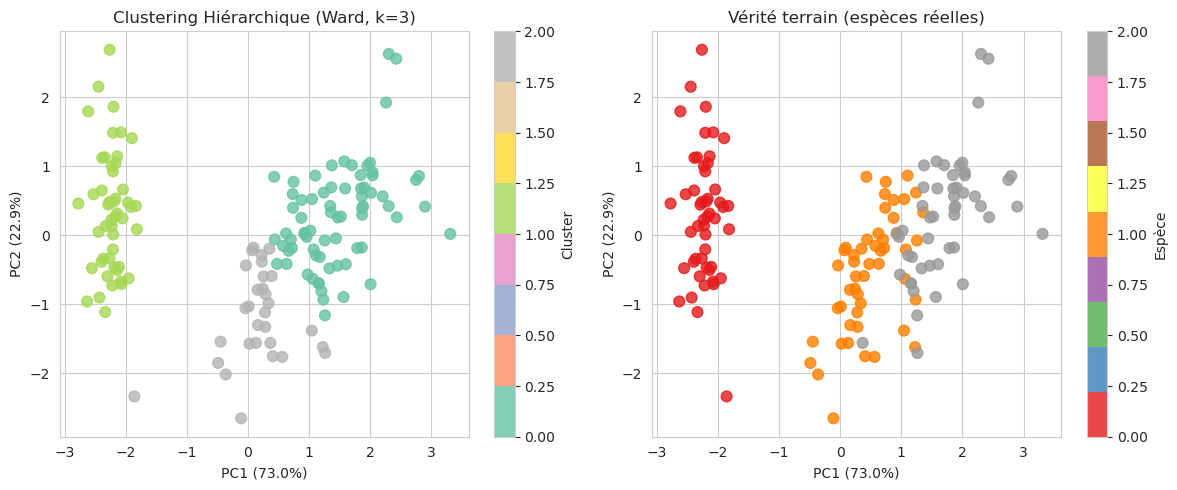

In [8]:
# Clustering hiérarchique avec 3 clusters
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_hc = hc.fit_predict(X_scaled)

# Réduction PCA pour visualisation 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 5))

# Plot clustering hiérarchique
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_hc, cmap='Set2', s=60, alpha=0.8)
plt.title("Clustering Hiérarchique (Ward, k=3)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.colorbar(scatter, label='Cluster')

# Plot vérité terrain
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='Set1', s=60, alpha=0.8)
plt.title("Vérité terrain (espèces réelles)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.colorbar(scatter2, label='Espèce')

plt.tight_layout()
plt.savefig('hc_result.png', dpi=100, bbox_inches='tight')
plt.show()


### 3.3 Comparaison des linkages

Le cours présente 3 types de linkage : **simple**, **average**, **complete**. Comparons-les !


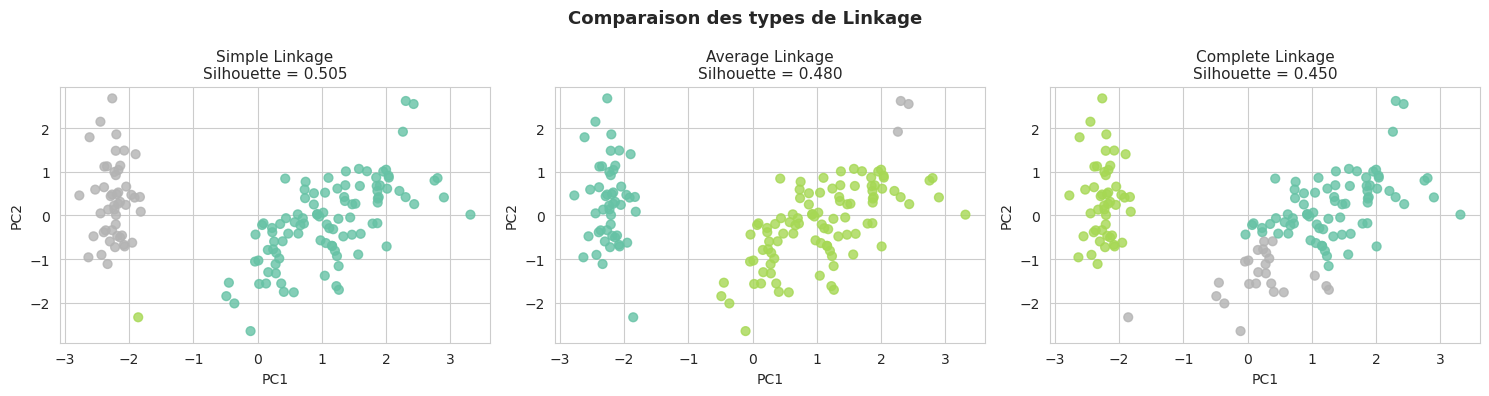

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
linkages = ['single', 'average', 'complete']
titles = ['Simple Linkage', 'Average Linkage', 'Complete Linkage']

for ax, lnk, title in zip(axes, linkages, titles):
    model = AgglomerativeClustering(n_clusters=3, linkage=lnk)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='Set2', s=40, alpha=0.8)
    ax.set_title(f"{title}\nSilhouette = {score:.3f}", fontsize=11)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.suptitle("Comparaison des types de Linkage", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('linkage_comparison.png', dpi=100, bbox_inches='tight')
plt.show()


---

## 4. K-Means (Chapitre 2)

K-Means optimise la somme des distances intra-cluster (inertie). C'est un algorithme **heuristique** (Lloyd) qui peut converger vers un minimum local.

### 4.1 Méthode du Coude (Elbow Method)

Pour trouver le bon **k**, on trace l'inertie en fonction du nombre de clusters.


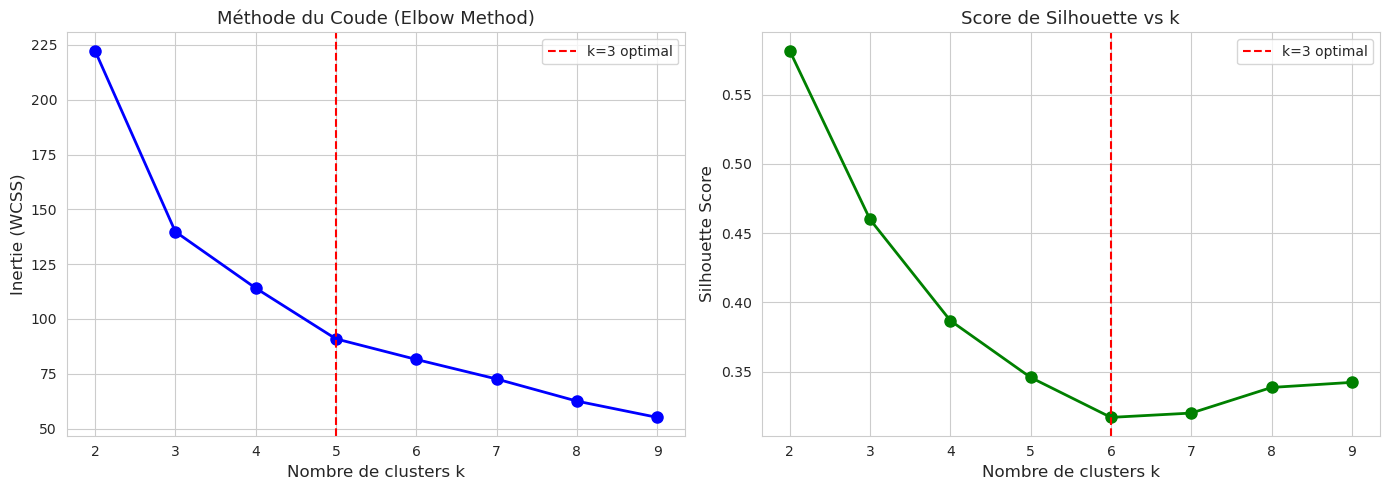

In [10]:
inertias = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=5, color='red', linestyle='--', label='k=3 optimal')
ax1.set_xlabel("Nombre de clusters k", fontsize=12)
ax1.set_ylabel("Inertie (WCSS)", fontsize=12)
ax1.set_title("Méthode du Coude (Elbow Method)", fontsize=13)
ax1.legend()

ax2.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.axvline(x=6, color='red', linestyle='--', label='k=3 optimal')
ax2.set_xlabel("Nombre de clusters k", fontsize=12)
ax2.set_ylabel("Silhouette Score", fontsize=12)
ax2.set_title("Score de Silhouette vs k", fontsize=13)
ax2.legend()

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=100, bbox_inches='tight')
plt.show()


### 4.2 Application K-Means avec k=5

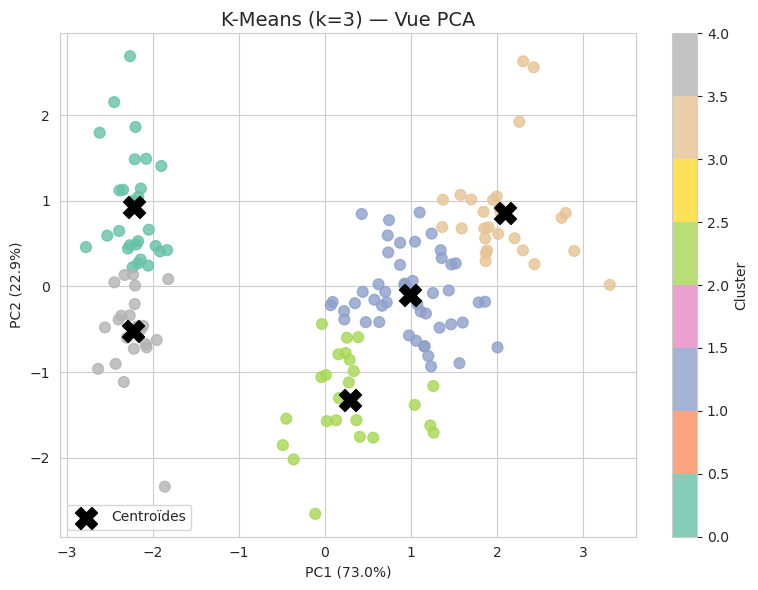

Inertie finale : 90.93
Nombre d'itérations : 8


In [11]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_scaled)
centroids = kmeans.cluster_centers_

# Reprojeter les centroïdes en PCA
centroids_pca = pca.transform(centroids)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_km, cmap='Set2', s=60, alpha=0.8)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='black', marker='X', s=250, zorder=5, label='Centroïdes')
plt.title("K-Means (k=3) — Vue PCA", fontsize=14)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.tight_layout()
plt.savefig('kmeans_result.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Inertie finale : {kmeans.inertia_:.2f}")
print(f"Nombre d'itérations : {kmeans.n_iter_}")


---

## 5. DBSCAN (Chapitre 3)

DBSCAN est un algorithme **basé sur la densité**. Il ne nécessite pas de spécifier k, mais deux hyperparamètres :
- **epsilon (ε)** : rayon de voisinage
- **min_samples** : nombre minimum de points pour former un cœur de cluster

Il identifie automatiquement les **outliers** (bruit).

### 5.1 Choix de epsilon — Courbe k-distance


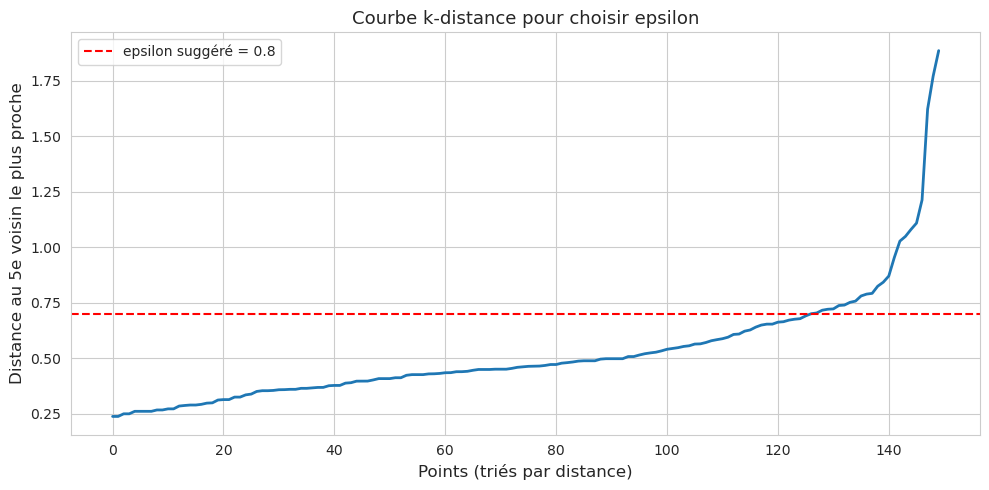

In [12]:
from sklearn.neighbors import NearestNeighbors

# Trouver les distances aux k plus proches voisins pour choisir epsilon
k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
distances = np.sort(distances[:, k-1])

plt.figure(figsize=(10, 5))
plt.plot(distances, linewidth=2)
plt.axhline(y=0.7, color='red', linestyle='--', label='epsilon suggéré = 0.8')
plt.xlabel("Points (triés par distance)", fontsize=12)
plt.ylabel(f"Distance au {k}e voisin le plus proche", fontsize=12)
plt.title("Courbe k-distance pour choisir epsilon", fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('kdistance.png', dpi=100, bbox_inches='tight')
plt.show()


### 5.2 Application DBSCAN

Nombre de clusters trouvés : 2
Points de bruit (outliers) : 4 (2.7%)


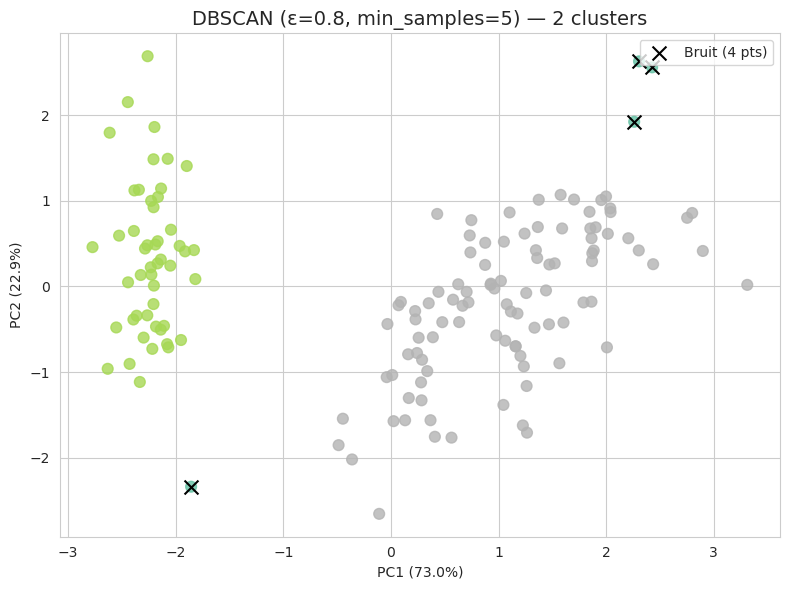

In [13]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)

n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = list(labels_db).count(-1)

print(f"Nombre de clusters trouvés : {n_clusters}")
print(f"Points de bruit (outliers) : {n_noise} ({n_noise/len(labels_db)*100:.1f}%)")

plt.figure(figsize=(8, 6))
# Couleurs spéciales pour le bruit (-1)
colors = ['red' if l == -1 else plt.cm.Set2(l/max(labels_db)) for l in labels_db]
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_db, cmap='Set2', s=60, alpha=0.8)
# Mettre en évidence les outliers
noise_mask = labels_db == -1
plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
            c='black', s=100, marker='x', zorder=5, label=f'Bruit ({n_noise} pts)')
plt.title(f"DBSCAN (ε=0.8, min_samples=5) — {n_clusters} clusters", fontsize=14)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend()
plt.tight_layout()
plt.savefig('dbscan_result.png', dpi=100, bbox_inches='tight')
plt.show()


---

## 6. Évaluation et Comparaison des Algorithmes (Chapitre 4)

Maintenant que nous avons les labels de chaque algorithme, comparons leurs performances avec des métriques.


In [14]:
# Calcul des métriques pour chaque algorithme
results = {}

algos = {
    'Hiérarchique (Ward)': labels_hc,
    'K-Means': labels_km,
    'DBSCAN': labels_db
}

print("="*65)
print(f"{'Algorithme':<25} {'Silhouette':>12} {'ARI':>10} {'N clusters':>12}")
print("="*65)

for name, labels in algos.items():
    # Silhouette uniquement sur les points non-bruit
    mask = labels != -1
    if mask.sum() > 1 and len(set(labels[mask])) > 1:
        sil = silhouette_score(X_scaled[mask], labels[mask])
    else:
        sil = float('nan')
    ari = adjusted_rand_score(y_true, labels)
    n_cl = len(set(labels)) - (1 if -1 in labels else 0)
    results[name] = {'silhouette': sil, 'ari': ari, 'n_clusters': n_cl}
    print(f"{name:<25} {sil:>12.3f} {ari:>10.3f} {n_cl:>12}")

print("="*65)
print("\n📌 ARI (Adjusted Rand Index) : 1.0 = parfait, 0 = aléatoire")
print("📌 Silhouette : +1 = clusters bien séparés, -1 = mauvais clustering")


Algorithme                  Silhouette        ARI   N clusters
Hiérarchique (Ward)              0.447      0.615            3
K-Means                          0.346      0.435            5
DBSCAN                           0.598      0.552            2

📌 ARI (Adjusted Rand Index) : 1.0 = parfait, 0 = aléatoire
📌 Silhouette : +1 = clusters bien séparés, -1 = mauvais clustering


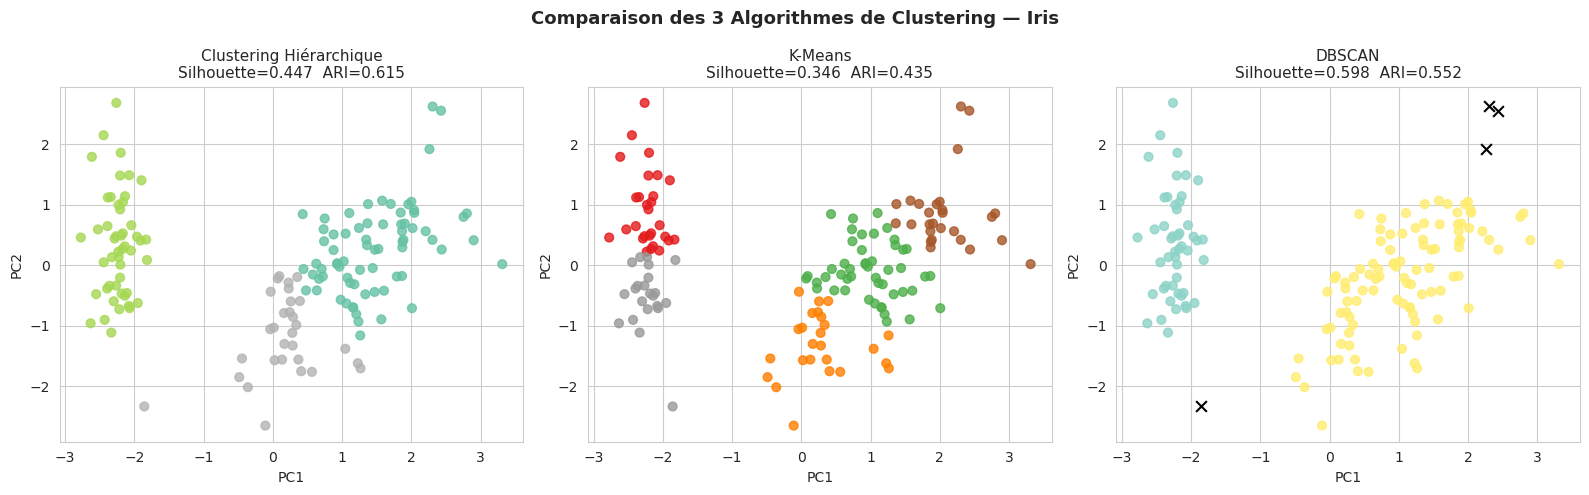

In [15]:
# Visualisation récapitulative
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

algo_items = list(algos.items())
cmaps = ['Set2', 'Set1', 'Set3']
titles_full = ['Clustering Hiérarchique', 'K-Means', 'DBSCAN']

for ax, (name, labels), cmap, title in zip(axes, algo_items, cmaps, titles_full):
    mask = labels != -1
    sc = ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=labels[mask], cmap=cmap, s=40, alpha=0.8)
    if not mask.all():
        ax.scatter(X_pca[~mask, 0], X_pca[~mask, 1], c='black', s=60, marker='x', label='Bruit')
    r = results[name]
    ax.set_title(f"{title}\nSilhouette={r['silhouette']:.3f}  ARI={r['ari']:.3f}", fontsize=11)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.suptitle("Comparaison des 3 Algorithmes de Clustering — Iris", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison.png', dpi=100, bbox_inches='tight')
plt.show()


---

## 7. Bilan et Conclusions

| Algorithme | Avantages | Inconvénients |
|---|---|---|
| **Hiérarchique** | Déterministe, pas besoin de k a priori, dendrogramme lisible | O(n³) complexité, lent sur grands datasets |
| **K-Means** | Rapide, scalable, simple | Non-déterministe, minimum local, nécessite k, clusters convexes |
| **DBSCAN** | Détecte les formes non-convexes, identifie les outliers, pas de k | Sensible à ε et min_samples, difficile en haute dimension |

### 🏆 Sur Iris :
- Les trois algorithmes donnent de bons résultats car les clusters sont bien séparés et relativement convexes.
- K-Means et Hiérarchique (Ward) ont les meilleures scores.
- DBSCAN identifie quelques outliers mais retrouve correctement les structures.

> 💡 **Règle d'or** : Il n'existe pas d'algorithme universellement meilleur. Le choix dépend de la forme des clusters, de la taille des données et du bruit attendu.
